# Limpieza de datos — etinverterxw (inversores XW)

## Índice del proceso

- **Bloque 0 — Imports**
- **Bloque 1 — Carga**
- **Bloque 2 — Conversión de tipos y selección de columnas**
- **Bloque 3 — Descripción estadística**
  - 3.1 Info
  - 3.2 — Distribución temporal y por entidad
    - Celda A — Registros por día
    - Celda B — Registros por hora del día
    - Celda C — Registros por entity_id
  - 3.3 — Distribuciones de variables numéricas
    - Histograma y boxplot de: `energyfrombattery`, `energytobattery`, `gridinputenergy`, `gridoutputenergy`
- **Bloque 4 — Limpieza de atípicos**
  - 4.1 — Conversión a numéricos
  - 4.2 — Validación de rangos físicos
  - 4.3 — Eliminación de filas sin información esencial
- **Bloque 5 — Resample horario: energía incremental (last + diff) y bandera de cobertura**
  - 5.1 — Contador al cierre de cada hora + cobertura cruda
  - 5.2 — Delta horario + banderas de calidad
- **Bloque 6 — Exportación**

> A diferencia de los notebooks de smartmeter y sensor card, aquí las cuatro variables son
> **contadores acumulados**, así que el Bloque 5 no promedia: toma el último valor de cada
> hora y calcula la diferencia entre horas consecutivas.

## Bloque 0 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

## Bloque 1 — Carga

In [ ]:
from pathlib import Path

# Cambiar según el formato de los archivos fuente: 'csv' o 'xlsx'
FORMAT = 'csv'

# Solo se ingieren los archivos del inversor XW (no los del resto de entidades)
SOURCE_GLOB = 'etinverterxw_*'

# Los archivos vienen con estos dos encabezados en español; el resto del
# proyecto los usa con estos nombres
COL_MAP = {
    'Fecha y Hora': 'time_index_colombia',
    'ID Entidad':   'entity_id',
}

# Según el FORMAT de arriba, se arma la lista de archivos y se define cómo leerlos
if FORMAT == 'csv':
    files = sorted(Path('.').glob(f'{SOURCE_GLOB}.csv'))
    def load(f):
        return pd.read_csv(f, sep=',', low_memory=False)

elif FORMAT == 'xlsx':
    files = sorted(Path('.').glob(f'{SOURCE_GLOB}.xlsx'))
    def load(f):
        return pd.read_excel(f)

print(f'{len(files)} archivos encontrados:')
for f in files:
    print(' ', f.name)

# Se lee archivo por archivo, se renombran las columnas y se van guardando en una lista
partes = []
for f in files:
    chunk = load(f)
    chunk.rename(columns=COL_MAP, inplace=True)
    partes.append(chunk)

# Todo queda en un solo DataFrame. join='outer' conserva cualquier columna
# aunque no esté en todos los archivos; ignore_index reinicia la numeración de filas
df = pd.concat(partes, join='outer', ignore_index=True)

# Avisar si algún archivo tiene columnas distintas al resto
# (todas las columnas que existen) − (las que están en TODOS) = las que faltan en alguno
col_sets = [set(p.columns) for p in partes]
extra = set.union(*col_sets) - set.intersection(*col_sets)
if extra:
    print('Columnas inconsistentes entre archivos:', extra)

print(f'Shape combinado: {df.shape}')
df.head()

## Bloque 2 — Conversión de tipos y selección de columnas

In [ ]:
# El archivo trae 68 columnas del inversor; de todas ellas solo se conservan la marca
# de tiempo, la entidad y las cuatro que alimentan indicadores del proyecto:
#   energyfrombattery, energytobattery -> EB (eficiencia de batería)
#   gridinputenergy, gridoutputenergy  -> KPI 07 (autosuficiencia / export a red)
COLS = ['time_index_colombia', 'entity_id',
        'energyfrombattery', 'energytobattery', 'gridinputenergy', 'gridoutputenergy']
df = df[COLS].copy()

df['time_index_colombia'] = pd.to_datetime(df['time_index_colombia'], utc=False, format='%Y-%m-%d %H:%M:%S')
df['entity_id'] = df['entity_id'].astype('category')

num_cols = ['energyfrombattery', 'energytobattery', 'gridinputenergy', 'gridoutputenergy']
for col in num_cols:
    # Lo que no se pueda convertir queda como NaN; esas filas se eliminan en el Bloque 4
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.dtypes)

## Bloque 3 — Descripción estadística

### 3.1 Info

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10167 entries, 0 to 10166
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   time_index_colombia  10167 non-null  datetime64[ns]
 1   entity_id            10167 non-null  category      
 2   energyfrombattery    10167 non-null  float64       
 3   energytobattery      10167 non-null  float64       
 4   gridinputenergy      10167 non-null  float64       
 5   gridoutputenergy     10167 non-null  float64       
dtypes: category(1), datetime64[ns](1), float64(4)
memory usage: 407.3 KB


In [5]:
df.describe(include='all')

,time_index_colombia,entity_id,energyfrombattery,energytobattery,gridinputenergy,gridoutputenergy
count,10167,10167,1.016700e+04,1.016700e+04,10167.000000,10167.000000
unique,NaN,3,NaN,NaN,NaN,NaN
top,NaN,Inverter_XW:12,NaN,NaN,NaN,NaN
freq,NaN,3411,NaN,NaN,NaN,NaN
mean,2026-04-02 12:06:35.971574528,NaN,1.606473e+03,2.416708e+03,46611.838298,788.276782
min,2026-01-30 19:37:37,NaN,1.033655e+03,1.850369e+03,39758.605000,703.271000
25%,2026-03-01 07:20:28,NaN,1.033865e+03,1.880453e+03,41828.470500,703.272000
50%,2026-03-28 19:02:07,NaN,1.050060e+03,2.007592e+03,48435.324000,827.621000
75%,2026-04-30 17:41:08.500000,NaN,1.471043e+03,2.089193e+03,49644.300000,833.168000
max,2026-06-05 21:58:41,NaN,4.294968e+06,4.294968e+06,51768.957000,833.168000


### 3.2 — Distribución temporal y por entidad

**Celda A — Registros por día**

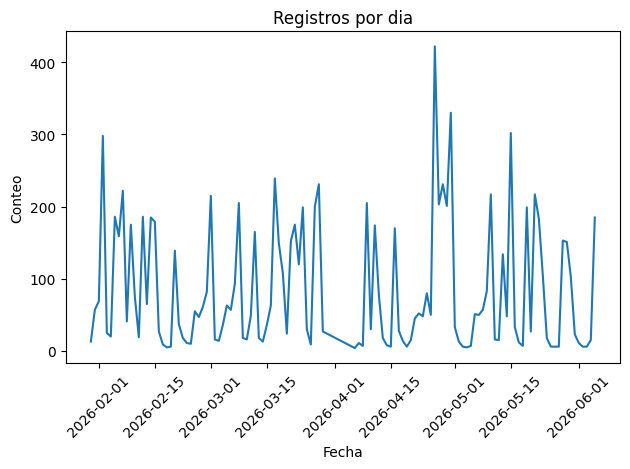

In [6]:
by_day = df.groupby(df['time_index_colombia'].dt.date).size()
fig, ax = plt.subplots()
ax.plot(by_day.index, by_day.values)
ax.set_xlabel('Fecha')
ax.set_ylabel('Conteo')
ax.set_title('Registros por dia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Celda B — Registros por hora del día**

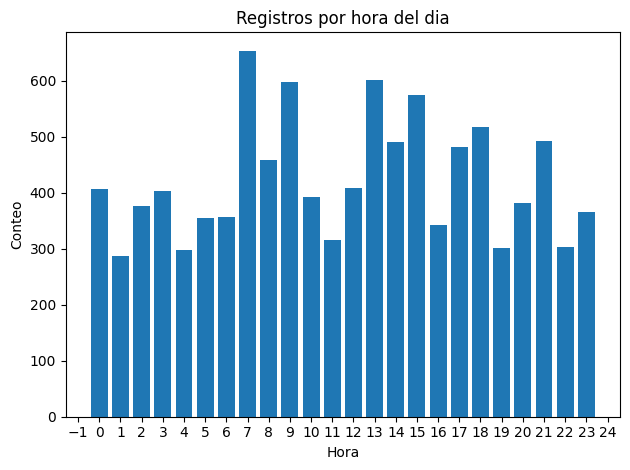

In [7]:
by_hour = df.groupby(df['time_index_colombia'].dt.hour).size()
fig, ax = plt.subplots()
ax.bar(by_hour.index, by_hour.values)
ax.set_xlabel('Hora')
ax.set_ylabel('Conteo')
ax.set_title('Registros por hora del dia')
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.tight_layout()
plt.show()

**Celda C — Registros por entity_id**

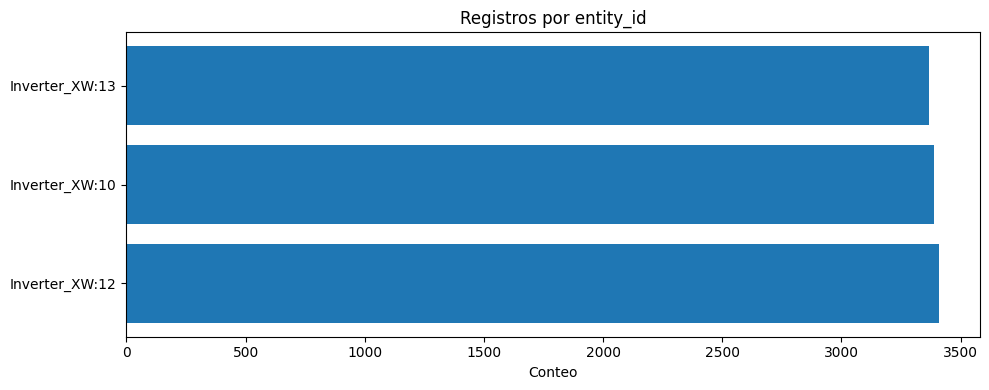

In [8]:
by_entity = df['entity_id'].value_counts()
fig, ax = plt.subplots(figsize=(10, max(4, len(by_entity) * 0.3)))
ax.barh(by_entity.index.astype(str), by_entity.values)
ax.set_xlabel('Conteo')
ax.set_title('Registros por entity_id')
plt.tight_layout()
plt.show()

### 3.3 — Distribuciones de variables numéricas

**energyfrombattery — histograma**

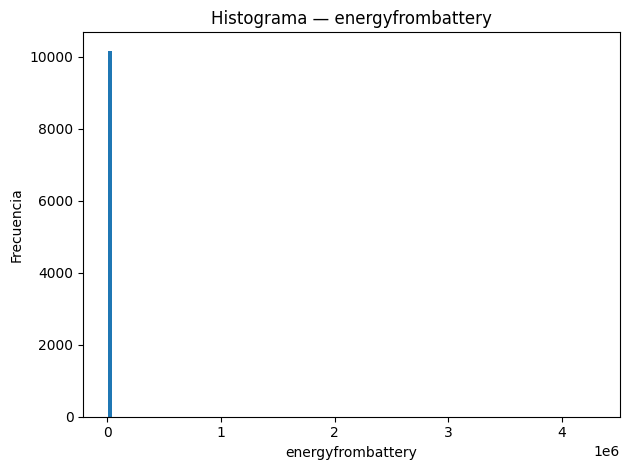

In [9]:
fig, ax = plt.subplots()
ax.hist(df['energyfrombattery'].dropna(), bins=100)
ax.set_xlabel('energyfrombattery')
ax.set_ylabel('Frecuencia')
ax.set_title('Histograma — energyfrombattery')
plt.tight_layout()
plt.show()

**energyfrombattery — boxplot**

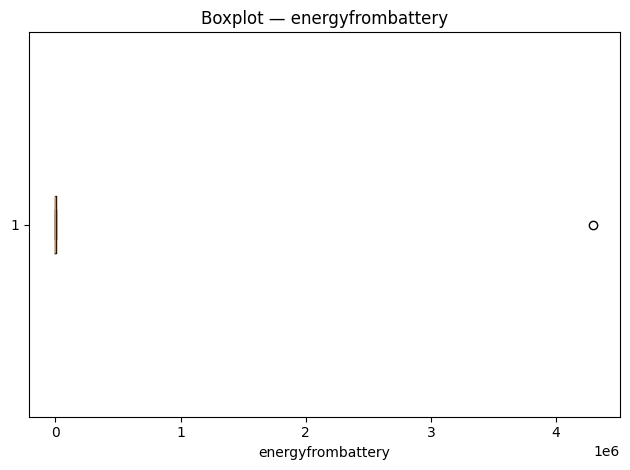

In [10]:
fig, ax = plt.subplots()
ax.boxplot(df['energyfrombattery'].dropna(), vert=False)
ax.set_xlabel('energyfrombattery')
ax.set_title('Boxplot — energyfrombattery')
plt.tight_layout()
plt.show()

**energytobattery — histograma**

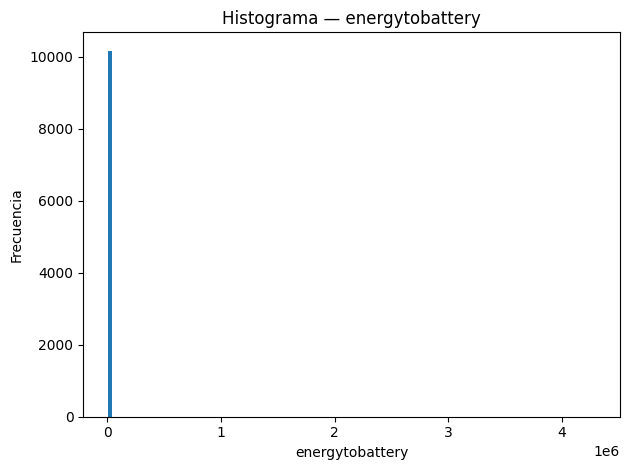

In [11]:
fig, ax = plt.subplots()
ax.hist(df['energytobattery'].dropna(), bins=100)
ax.set_xlabel('energytobattery')
ax.set_ylabel('Frecuencia')
ax.set_title('Histograma — energytobattery')
plt.tight_layout()
plt.show()

**energytobattery — boxplot**

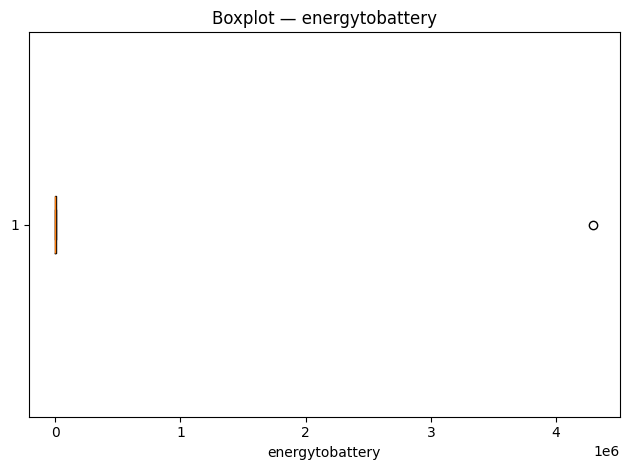

In [12]:
fig, ax = plt.subplots()
ax.boxplot(df['energytobattery'].dropna(), vert=False)
ax.set_xlabel('energytobattery')
ax.set_title('Boxplot — energytobattery')
plt.tight_layout()
plt.show()

**gridinputenergy — histograma**

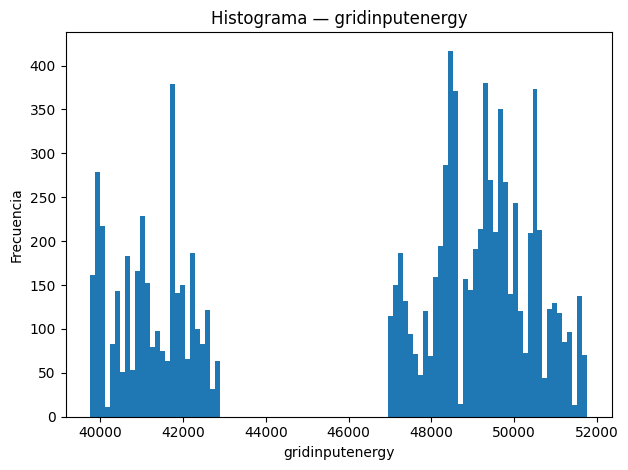

In [13]:
fig, ax = plt.subplots()
ax.hist(df['gridinputenergy'].dropna(), bins=100)
ax.set_xlabel('gridinputenergy')
ax.set_ylabel('Frecuencia')
ax.set_title('Histograma — gridinputenergy')
plt.tight_layout()
plt.show()

**gridinputenergy — boxplot**

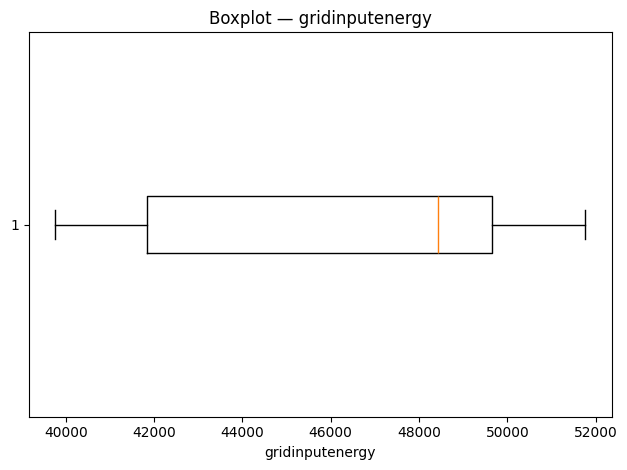

In [14]:
fig, ax = plt.subplots()
ax.boxplot(df['gridinputenergy'].dropna(), vert=False)
ax.set_xlabel('gridinputenergy')
ax.set_title('Boxplot — gridinputenergy')
plt.tight_layout()
plt.show()

**gridoutputenergy — histograma**

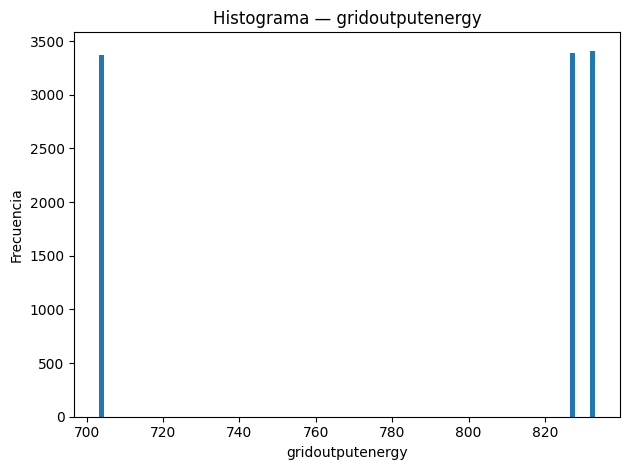

In [15]:
fig, ax = plt.subplots()
ax.hist(df['gridoutputenergy'].dropna(), bins=100)
ax.set_xlabel('gridoutputenergy')
ax.set_ylabel('Frecuencia')
ax.set_title('Histograma — gridoutputenergy')
plt.tight_layout()
plt.show()

**gridoutputenergy — boxplot**

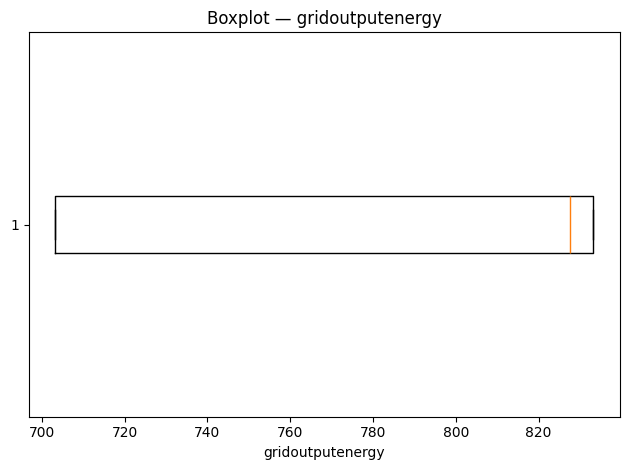

In [16]:
fig, ax = plt.subplots()
ax.boxplot(df['gridoutputenergy'].dropna(), vert=False)
ax.set_xlabel('gridoutputenergy')
ax.set_title('Boxplot — gridoutputenergy')
plt.tight_layout()
plt.show()

## Bloque 4 — Limpieza de atípicos

### 4.1 — Conversión a numéricos

In [ ]:
# Se repite la conversión del Bloque 2 para poder correr la limpieza sola,
# sin tener que volver a ejecutar todo el notebook desde el inicio
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

### 4.2 — Validación de rangos físicos

In [ ]:
print('NaNs antes:')
print(df[num_cols].isna().sum())

## Contadores acumulados de energía (Wh). El valor centinela 4294967.295
## (2**32-1 / 1000) es un desbordamiento uint32 del sensor -> se descarta.
## El tope de 1.000.000 Wh deja pasar cualquier lectura real del inversor
## y solo corta ese centinela.
RANGES = {
    'energyfrombattery': (0, 1_000_000),
    'energytobattery':   (0, 1_000_000),
    'gridinputenergy':   (0, 1_000_000),
    'gridoutputenergy':  (0, 1_000_000),
}

## Lo que queda fuera de rango no se borra aquí: se marca como NaN.
## La fila completa recién se elimina en el 4.3.
for col, (lo, hi) in RANGES.items():
    df[col] = df[col].where(df[col].between(lo, hi))

print('NaNs despues:')
print(df[num_cols].isna().sum())

### 4.3 — Eliminación de filas sin información esencial

In [ ]:
## Cae la fila entera si le falta cualquier columna: tanto los vacíos que ya venían
## del origen como los valores que quedaron fuera de rango en el 4.2
before = len(df)
df.dropna(inplace=True)
print(f'Filas eliminadas: {before - len(df)}  — shape resultante: {df.shape}')

## Bloque 5 — Resample horario: energía incremental (last + diff) y bandera de cobertura

Los cuatro campos son **contadores acumulados**; promediarlos (mean) no tiene sentido físico.
EB (`Σ E_from/Σ E_to`) y KPI 07 (autosuficiencia) necesitan **energía por intervalo =
diferencia del contador entre extremos**. Por eso:

- **5.1** — valor acumulado al **cierre de cada hora** (`last`) + nº de muestras crudas por hora (`n_muestras`).
- **5.2** — **delta horario** (`diff` por entidad) + banderas de calidad (`gap_h`, `calidad`).

In [ ]:
## Este FREQ nos permite cambiar la frecuencia de resampleo de
## los datos, dependiendo de lo que requieran los Indicadores o KPIs
FREQ = '60min'

## Tolerancia de hueco: con FREQ='60min', dos horas contiguas están a 1 h de distancia.
## Si se cambia el FREQ hay que ajustar este umbral en la misma unidad (horas).
GAP_MAX_H = 1   # P5: horas contiguas = 'ok'; un salto mayor marca 'hueco'

# 5.1 — Contador al cierre de cada hora ('last', NO 'mean') y cobertura cruda por hora
## Se usa 'last' porque las cuatro variables son contadores acumulados: el promedio
## de un acumulado no representa nada físico, pero su último valor sí es el estado
## del inversor al cerrar la hora.
grp = df.set_index('time_index_colombia').groupby('entity_id', observed=True).resample(FREQ)
hourly = grp[num_cols].last()
hourly['n_muestras'] = grp.size()            # nº de lecturas crudas que cayeron en la hora
hourly = hourly.reset_index()

## El resample crea intervalos vacíos donde el inversor no reportó nada.
## Aquí se descartan: n_muestras == 0 significa hora sin ninguna lectura cruda.
# Solo horas con dato real (no se fabrican horas vacías)
hourly = hourly[hourly['n_muestras'] > 0].copy()

print('Horas con dato por entidad:')
print(hourly.groupby('entity_id', observed=True).size())

In [ ]:
# 5.2 — Energía por hora = diferencia del contador entre horas-con-dato consecutivas (por entidad)
## Se ordena por entidad y tiempo porque el diff() de abajo depende del orden de las filas;
## el groupby evita que el delta de un inversor se calcule contra el de otro.
df_h = hourly.sort_values(['entity_id', 'time_index_colombia']).copy()
gb = df_h.groupby('entity_id', observed=True)

# P5: separación (en horas) respecto a la hora-con-dato previa; 1.0 = contigua
df_h['gap_h'] = gb['time_index_colombia'].diff().dt.total_seconds() / 3600

# P4: delta del contador -> energía consumida/entregada en el intervalo
for c in num_cols:
    d = gb[c].diff()
    ## Un contador acumulado nunca debería bajar: si baja, es un reinicio del equipo
    ## o una lectura corrupta, así que ese delta no es energía real.
    d[d < 0] = np.nan                        # delta negativo = reset/atípico -> se anula
    df_h[c + '_delta'] = d

# P5: bandera de calidad del delta
## No se borran los deltas que atraviesan un hueco: se marcan, y quien calcule
## el indicador decide si los usa o los filtra por 'calidad'.
df_h['calidad'] = np.where(df_h['gap_h'] <= GAP_MAX_H, 'ok', 'hueco')
df_h.loc[df_h['gap_h'].isna(), 'calidad'] = 'inicio'   # 1ª hora de cada entidad: sin delta

## Se exportan los deltas (no los acumulados) más las columnas de calidad,
## que es lo que consumen EB y el KPI 07.
out_cols = (['entity_id', 'time_index_colombia']
            + [c + '_delta' for c in num_cols]
            + ['n_muestras', 'gap_h', 'calidad'])
df_resampled = df_h[out_cols]

# Se descartan las filas 'inicio' (delta no calculable)
df_resampled = df_resampled[df_resampled['calidad'] != 'inicio'].reset_index(drop=True)

print('shape:', df_resampled.shape)
print()
print('Distribución de calidad:')
print(df_resampled['calidad'].value_counts())
print()
print('% de horas con delta que atraviesan un hueco:',
      round(100 * (df_resampled['calidad'] == 'hueco').mean(), 1), '%')

## Bloque 6 — Exportación

In [22]:
csv_path     = 'clean_etinverterxw.csv'
parquet_path = 'clean_etinverterxw.parquet'

df_resampled.to_csv(csv_path, index=False)
df_resampled.to_parquet(parquet_path, engine='pyarrow', index=False)

print(f'CSV guardado en:     {csv_path}  — shape: {df_resampled.shape}')
print(f'Parquet guardado en: {parquet_path}  — shape: {df_resampled.shape}')
print()
print('Columnas:', list(df_resampled.columns))

CSV guardado en:     clean_etinverterxw.csv  — shape: (4302, 9)
Parquet guardado en: clean_etinverterxw.parquet  — shape: (4302, 9)

Columnas: ['entity_id', 'time_index_colombia', 'energyfrombattery_delta', 'energytobattery_delta', 'gridinputenergy_delta', 'gridoutputenergy_delta', 'n_muestras', 'gap_h', 'calidad']
